In [2]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection
from matplotlib.colors import ListedColormap
from matplotlib.colors import LinearSegmentedColormap
from matplotlib import gridspec
import sympy as sp
from matplotlib import cm
from sympy import symbols, diff
from scipy.optimize import root
from matplotlib.colors import Normalize
from joblib import Parallel, delayed
import pickle
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

In [2]:
tr = np.load('turing_region.npz')
X = tr['X']
Y = tr['Y']
Turing_region = tr['Turing_region']

In [3]:
def laplacian_neumann(u, dx):
    # Pad with edge values (ghost cells): enforces ∂u/∂n = 0 at the boundary
    up = np.pad(u, pad_width=1, mode='edge')
    return (
        up[2:, 1:-1] + up[:-2, 1:-1] + up[1:-1, 2:] + up[1:-1, :-2]
        - 4.0 * up[1:-1, 1:-1]
    ) / (dx**2)
def simulate_two_step_euler_maruyama_with_storage(
    y0, t0, t_max, dt, c, dx, bound_cond, modelfuns, r,
    noise_amp, v_r, v_theta, cent_cyc, k1_0, k2_0,tangential_noise, radial_noise,nx,ny
):
    def laplacian(u):
        return laplacian_neumann(u, dx)
    
    b_a, v_a, k_a,a_conc,b_conc, k_ba, mu_a = symbols('b_a v_a k_a a_conc b_conc k_ba mu_a', real=True)
    r_d_a = b_a + v_a * 1 / (1 + (k_a / a_conc) ** 2) * 1 / (1 + (b_conc / k_ba) ** 2) - mu_a * a_conc
    b_b, v_b, k_ab,a_conc,b_conc, mu_b = symbols('b_b v_b k_ab a_conc b_conc mu_b', real=True)
    r_d_b = b_b + v_b * 1 / (1 + (k_ab / a_conc) ** 2) - mu_b * b_conc
    r_d_a_a = diff(r_d_a, a_conc)
    r_d_a_b = diff(r_d_a, b_conc)
    r_d_b_b = diff(r_d_b, b_conc)
    r_d_b_a = diff(r_d_b, a_conc)
    # Setup initial conditions
    #n = int(np.sqrt(len(y0[:-2]) // 2))  # infer grid size
    params = c
    mod_pars = params[2:]
    ss1 = solve_ss(k1_0,k2_0,params)[0]
    ss2 = solve_ss(k1_0,k2_0,params)[1]
    ss_1 = solve_ss2(k1_0,k2_0,params,[ss1,ss2])[0]
    ss_2 = solve_ss2(k1_0,k2_0,params,[ss1,ss2])[1]
    a = np.reshape(np.zeros(nx*ny) + float(ss_1),(nx,ny))
    b = np.reshape(np.zeros(nx*ny) + float(ss_2),(nx,ny)) 

    k1 = k1_0
    k2 = k2_0
    t = t0
    Da = params[0]
    Db = params[1]
    values_base = { v_a: mod_pars[0], k_ba: mod_pars[2], mu_a: mod_pars[5],
        b_b: mod_pars[4], v_b: mod_pars[1], mu_b: mod_pars[6] # Fixed values
    }
    k_values = np.linspace(0, 2, 100)
    results = []  # List to store time, concentrations, and rate constants
    n = 0
    while t < t_max/(v_theta/0.01):

        # FF_trig = 1
        # if FF_trig:
        #     b_a_spatial = mod_pars[3] + FF_data
        # else:
        b_a_spatial = None

        f1_now, f2_now = modelfuns[0](a, b, mod_pars, k1, k2, b_a_spatial)

        g1_now, g2_now = modelfuns[1](k1, k2, r, v_r, v_theta, cent_cyc,tangential_noise, radial_noise)

        Da = params[0]
        Db = params[1]

        lap_a = laplacian(a)
        lap_b = laplacian(b)

        # First Euler-Maruyama step (predict)
        dydt_a = Da * lap_a + f1_now 
        dydt_b = Db * lap_b + f2_now 

        # Predict concentrations (Euler step)
        a_pred = a + dt * dydt_a
        b_pred = b + dt * dydt_b

        k1_pred = k1 + dt * g1_now
        k2_pred = k2 + dt * g2_now

        # Get the predicted reaction terms for the predicted concentrations
        f1_pred, f2_pred = modelfuns[0](a_pred, b_pred, mod_pars, k1_pred, k2_pred, b_a_spatial)
        g1_pred, g2_pred = modelfuns[1](k1_pred, k2_pred, r, v_r, v_theta, cent_cyc,tangential_noise, radial_noise)

        # Second Euler-Maruyama step (corrected)
        lap_a_pred = laplacian(a_pred)
        lap_b_pred = laplacian(b_pred)

        dydt_a_pred = Da * lap_a_pred + f1_pred 
        dydt_b_pred = Db * lap_b_pred + f2_pred

        # Combine the two steps (Heun-like method)
        noise_a = a*(noise_amp * np.sqrt(dt) * np.random.randn(*a.shape))
        noise_b = b*(noise_amp * np.sqrt(dt) * np.random.randn(*b.shape))

        # Final update step using both predicted and current steps
        a += 0.5 * dt * (dydt_a + dydt_a_pred) + noise_a
        b += 0.5 * dt * (dydt_b + dydt_b_pred) + noise_b

        # Prevent negative or NaN values
        if np.any(a < 0):
            print("Warning: 'a' contains negative values:", a[a < 0])
        if np.any(b < 0):
            print("Warning: 'b' contains negative values:", b[b < 0])
        a = np.nan_to_num(a, nan=0.0, posinf=1e10, neginf=0.0)
        b = np.nan_to_num(b, nan=0.0, posinf=1e10, neginf=0.0)
        

        a = np.clip(a, 1e-10, None)  # Enforces a minimum of 0
        b = np.clip(b, 1e-10, None)

        
        # Compute the rate of change of k1 and k2 (using the limit cycle dynamics)
        k1 += 0.5 * dt * (g1_now + g1_pred)
        k2 += 0.5 * dt * (g2_now + g2_pred)
        # Store time, concentration, and parameters at each time step
        if int(n%(1/(dt*(v_theta/0.01)))) == 0.0: # v_theta/0.01 means if v_theta is larger than default(0.01)by 10 times, 
            #dt increases by 10 times, making 10 times more sampling than default.
            results.append({
                't': t,   # Current time
                'u': a.copy(),  # Concentration of A (u)
                'v': b.copy(),  # Concentration of B (v)
                'k1': k1,  # Reaction rate constant k1
                'k2': k2   # Reaction rate constant k2
            })
        n += 1
        t += dt


    return results

def soft_clip(x, floor=1e-10):
    return np.where(x < floor, floor, x)


def Net8_pat(a, b, mod_pars, k1, k2, b_a_spatial=None):
    v_a, v_b, k_ba, b_a_default, b_b, mu_a, mu_b = mod_pars
    k_a, k_ab = k1, k2

    a_safe = np.clip(a, 1e-8, None)
    b_safe = np.clip(b, 1e-8, None)

    # Use spatially varying b_a if provided
    b_a_used = b_a_spatial if b_a_spatial is not None else b_a_default

    f1 = b_a_used + v_a * (1 / (1 + (k_a / a_safe) ** 2)) * (1 / (1 + (b_safe / k_ba) ** 2)) - mu_a * a
    f2 = b_b + v_b * (1 / (1 + (k_ab / a_safe) ** 2)) - mu_b * b

    return f1, f2




def Net8_cycle(k1, k2, radius, speed_r, speed_theta, cent_cyc, tangential_noise, radial_noise):
    # Center coordinates
    k1star, k2star = cent_cyc
    x = k1 - k1star
    y = k2 - k2star
    r = np.sqrt(x**2 + y**2)

    # Core deterministic dynamics
    lin1 = x * (speed_r * (radius - r))
    lin2 = y * (speed_r * (radius - r))
    an1 = y * speed_theta
    an2 = x * speed_theta

    # Unit radial and tangential vectors
    if r == 0:
        unit_r = [1.0, 0.0]
        unit_t = [0.0, 1.0]
    else:
        unit_r = [x / r, y / r]
        unit_t = [-y / r, x / r]

    # Add radial noise (in/out movement)
    rad_noise = np.random.normal(0, radial_noise)
    rad_x = rad_noise * unit_r[0]
    rad_y = rad_noise * unit_r[1]

    # Add tangential noise (spin variation)
    tang_noise = np.random.normal(0, tangential_noise)
    tang_x = tang_noise * unit_t[0]
    tang_y = tang_noise * unit_t[1]

    # Final dynamics
    f1 = lin1 - an1 + rad_x + tang_x
    f2 = lin2 + an2 + rad_y + tang_y

    return f1, f2


def solve_ss(k1, k2, params):

    # Define symbolic variables
    a, b = sp.symbols('a b', real=True)
    b_a, v_a, k_a, k_ba, mu_a = sp.symbols('b_a v_a k_a k_ba mu_a', real=True)
    b_b, v_b, k_ab, mu_b = sp.symbols('b_b v_b k_ab mu_b', real=True)

    # Define steady-state equations
    r_d_a = b_a + v_a * 1 / (1 + (k_a / a) ** 2) * 1 / (1 + (b / k_ba) ** 2) - mu_a * a
    r_d_b = b_b + v_b * 1 / (1 + (k_ab / a) ** 2) - mu_b * b
    # Assign values to variables
    mod_pars = params[2:]
    values = {
        b_a: mod_pars[3], v_a: mod_pars[0], k_ba: mod_pars[2], mu_a: mod_pars[5],
        b_b: mod_pars[4], v_b: mod_pars[1], mu_b: mod_pars[6],k_a: k1,k_ab: k2,
    }

    # Convert symbolic expressions into numerical functions
    r_d_a_num = sp.lambdify((a, b), r_d_a.subs(values), 'numpy')
    r_d_b_num = sp.lambdify((a, b), r_d_b.subs(values), 'numpy')

    # Define system of equations
    def equations(vars):
        a, b = vars
        return np.array([r_d_a_num(a, b), r_d_b_num(a, b)])

    # Try multiple solvers for robustness
    initial_guesses = [[4, 2], [1, 1], [10, 5], [0.1, 0.1]]
    solvers = ['hybr', 'lm', 'broyden1', 'df-sane']
    
    for guess in initial_guesses:
        for method in solvers:
            result = root(equations, guess, method=method)
            if result.success:
                return result.x  # Return solution if successful

    raise RuntimeError("No solution found with tested solvers and initial guesses.")
def solve_ss2(k1, k2, params,given_sol):
    # Define symbolic variables
    a, b = sp.symbols('a b', real=True)
    b_a, v_a, k_a, k_ba, mu_a = sp.symbols('b_a v_a k_a k_ba mu_a', real=True)
    b_b, v_b, k_ab, mu_b = sp.symbols('b_b v_b k_ab mu_b', real=True)

    # Define steady-state equations
    r_d_a = b_a + v_a * 1 / (1 + (k_a / a) ** 2) * 1 / (1 + (b / k_ba) ** 2) - mu_a * a
    r_d_b = b_b + v_b * 1 / (1 + (k_ab / a) ** 2) - mu_b * b

    # Assign values to variables
    mod_pars = params[2:]
    values = {
        b_a: mod_pars[3],
        v_a: mod_pars[0],
        k_ba: mod_pars[2],
        mu_a: mod_pars[5],
        b_b: mod_pars[4],
        v_b: mod_pars[1],
        mu_b: mod_pars[6],
        k_a: k1,
        k_ab: k2,
    }

    # Convert symbolic expressions into numerical functions
    r_d_a_num = r_d_a.subs(values)
    r_d_b_num = r_d_b.subs(values)

    # Define system of equations
    def equations(vars):
        a_val, b_val = vars
        return np.array([r_d_a_func(a_val, b_val), r_d_b_func(a_val, b_val)])

    # steady_state = given_sol
    # u0 = sp.nsolve([r_d_a_num, r_d_b_num], [a, b], steady_state, prec = 100)
    # return u0

    # Try multiple initial guesses
    initial_guesses = [given_sol, [0.1, 0.1], [1, 1], [4, 2], [10, 5]]

    for guess in initial_guesses:
        try:
            sol = sp.nsolve([r_d_a_num, r_d_b_num], [a, b], guess, prec=20)
            return sol
        except Exception:
            continue

    raise RuntimeError("No solution found with any initial guess in solve_ss2")

In [5]:
r, v_r, v_theta = 5, 0.01, 0.01 # 8, 0.3, 0.006

bound_cond = "Neumann"
nx = 100
ny = 100

model_eq = [Net8_pat, Net8_cycle] 


params = [
    1,       # D_A: activator diffusion
    25,      # D_B: inhibitor diffusion (moderately faster than D_A)
    3500,     # V_A: 
    3500,    # V_B: 
    0.5,     # k_BA: 
    1,    # b_A: 
    1,    # b_B: 
    6,     # μ_A: 
    8       # μ_B: 
] 
mod_pars = params[2:]
dx = 0.5
factor = 1 

y0 = np.zeros(2 * nx * ny + 2)

dt = 0.002
noise_amp = 0.01
t_max = 630
v_theta = 0.01


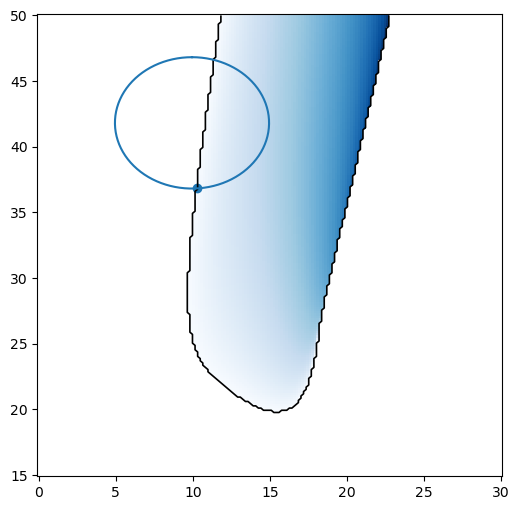

In [5]:
cent_cyc = [9.941821708064465, 41.81767050770186]
k1 = 10.269746954817379
k2 = 36.82843559315414
circle_vis_x = []
circle_vis_y = []
theta = np.linspace(0, 2*np.pi, 100)
circle_vis_x = cent_cyc[0] + r*np.sin(theta) 
circle_vis_y = cent_cyc[1] + r*np.cos(theta)
Z = Turing_region.copy().astype(float)
Z[Z <= 0] = np.nan

# Create colormap: Blues for >0, white for NaN
cmap = plt.cm.Blues.copy()
cmap.set_bad(color="white")  # NaN → white

# Continuous normalization (0 → light blue, 1 → dark blue)
norm = Normalize(vmin=0, vmax=np.max(Turing_region))
plt.figure(figsize=(6, 6))
plt.pcolormesh(X, Y, Z, shading="auto", cmap=cmap, norm=norm)
mask = ~np.isnan(Z)
plt.contour(X, Y, mask.astype(int), levels=[0.5], colors="black", linewidths=1.2)
plt.plot(circle_vis_x,circle_vis_y)
plt.scatter(k1,k2)

In [4]:
res =  np.load(f"TPLC_sensitivity_analysis_0.01.npz")# Use any trajectories or previous simulations
b_a, v_a, k_a,a,b, k_ba, mu_a = symbols('b_a v_a k_a a b k_ba mu_a', real=True)
r_d_a = b_a + v_a * 1 / (1 + (k_a / a) ** 2) * 1 / (1 + (b / k_ba) ** 2) - mu_a * a
b_b, v_b, k_ab,a,b, mu_b = symbols('b_b v_b k_ab a b mu_b', real=True)
r_d_b = b_b + v_b * 1 / (1 + (k_ab / a) ** 2) - mu_b * b
r_d_a_a = diff(r_d_a, a)
r_d_a_b = diff(r_d_a, b)

r_d_b_b = diff(r_d_b, b)
r_d_b_a = diff(r_d_b, a)

params = [
    1,       # D_A: 
    25,      # D_B: 
    3500,     # V_A: 
    3500,    # V_B: 
    0.5,     # k_BA: 
    1,    # b_A: 
    1,    # b_B: 
    6,     # μ_A: 
    8       # μ_B: 
] 

mod_pars = params[2:]
D_a = params[0]
D_b = params[1] 
turing_enter = []
turing_leave = []
sharp_dec = []
lambda_max = []
for index in range(0,len(res['k1'])):
    ss_1, ss_2 = solve_ss2(res['k1'][index], res['k2'][index],params,solve_ss(res['k1'][index], res['k2'][index],params))
    values = {
        b_a: mod_pars[3],
        v_a: mod_pars[0],
        k_a: res['k1'][index],
        a: ss_1, 
        b: ss_2, 
        k_ba: mod_pars[2],
        mu_a: mod_pars[5],
        b_b: mod_pars[4],
        v_b: mod_pars[1],
        k_ab: res['k2'][index],
        mu_b: mod_pars[6]
    }
    rdaa_numeric = r_d_a_a.subs(values).evalf()
    rdab_numeric = r_d_a_b.subs(values).evalf()
    rdba_numeric = r_d_b_a.subs(values).evalf()
    rdbb_numeric = r_d_b_b.subs(values).evalf()

    J = np.array([[rdaa_numeric,rdab_numeric], [rdba_numeric, rdbb_numeric]])
    J = np.array(J, dtype=float)
    eig_val = np.linalg.eig(J)[0]
    D_a = params[0]
    D_b = params[1] 
    k_values = np.linspace(0, 2, 200)
    real_lambda = []
    prev_eig_vals = [None, None]
    for k in k_values:
        J_diff = J - np.diag([D_a * k**2, D_b * k**2])
        eig_vals = np.real(np.linalg.eigvals(J_diff))
        max_real_lambda = np.max(eig_vals)
        real_lambda.append(max_real_lambda)    
        
    lambda_max.append(max(real_lambda))
    if lambda_max[index] >= 0 and lambda_max[index - 1] <0:
        print('Eigenvalues became positive at:',index)
        turing_enter.append(index)
    elif lambda_max[index] < 0 and lambda_max[index - 1] >= 0:
        print('Eigenvalues became negative at:', index)
        turing_leave.append(index)

Eigenvalues became negative at: 279
Eigenvalues became positive at: 628


In [5]:
lambda_max = np.array(lambda_max)
lambda_max_pos = lambda_max[lambda_max > 0]
mean_lambda = np.mean(lambda_max_pos)
print(mean_lambda)

0.42948828909108927


In [6]:
r, v_r, v_theta = 5, 0.01, 0.01
arclength = 2*np.pi*0.45*r
sensitivity_metric = mean_lambda*arclength/(r*v_theta)
print(sensitivity_metric)

121.43495284302738


In [7]:
target_sensitivity_metric = 7
v_theta_target = mean_lambda*arclength/(r*target_sensitivity_metric)
print(v_theta_target)

0.17347850406146767


In [10]:
result_sim = simulate_two_step_euler_maruyama_with_storage(
        y0=y0.copy(),
        t0=0,
        t_max=t_max,
        dt=dt,
        c=params,
        dx=0.5,
        bound_cond=bound_cond,
        modelfuns=model_eq,
        r=r,
        noise_amp=noise_amp,
        v_r=v_r,
        v_theta=v_theta,
        cent_cyc=cent_cyc,
        k1_0=k1,
        k2_0=k2,
        tangential_noise=0,
        radial_noise=0,
        nx =100,
        ny=100
    )
k1_values = []
k2_values = []
u_values = []
v_values = []
t_values = []
for i in range(len(result_sim)):
    k1_values.append(result_sim[i]['k1'])
    k2_values.append(result_sim[i]['k2'])
    u_values.append(result_sim[i]['u'])
    v_values.append(result_sim[i]['v'])
    t_values.append(result_sim[i]['t'])
np.savez(f"TPLC_sensitivity_analysis_10.npz", k1 = k1_values, k2 = k2_values, u = u_values, v = v_values, t = t_values)


KeyboardInterrupt



In [86]:
r, v_r, v_theta = 5, 0.01, 0.173
arclength = 2*np.pi*0.45*r
sensitivity_metric = mean_lambda*arclength/(r*v_theta)
print(sensitivity_metric)

result_sim = simulate_two_step_euler_maruyama_with_storage(
        y0=y0.copy(),
        t0=0,
        t_max=630,
        dt=0.0002, #Alter appropriately depending on speed using.
        c=params,
        dx=0.5,
        bound_cond=bound_cond,
        modelfuns=model_eq,
        r=r,
        noise_amp=noise_amp,
        v_r=v_r,
        v_theta=v_theta,
        cent_cyc=cent_cyc,
        k1_0=k1,
        k2_0=k2,
        tangential_noise=0,
        radial_noise=0,
        nx =100,
        ny=100
    )
k1_values = []
k2_values = []
u_values = []
v_values = []
t_values = []
for i in range(len(result_sim)):
    k1_values.append(result_sim[i]['k1'])
    k2_values.append(result_sim[i]['k2'])
    u_values.append(result_sim[i]['u'])
    v_values.append(result_sim[i]['v'])
    t_values.append(result_sim[i]['t'])
np.savez(f"TPLC_sensitivity_analysis_{v_theta}.npz", k1 = k1_values, k2 = k2_values, u = u_values, v = v_values, t = t_values)

7.019361436013143


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# Load data
vel = 0.5
res = np.load(f"TPLC_sensitivity_analysis_{vel}.npz")
data = res['u']

fig, ax = plt.subplots()
im = ax.imshow(data[0], cmap="viridis")  # No fixed vmin/vmax
ax.set_title("Frame 0")

def update(frame):
    # Update the image data
    im.set_data(data[frame])
    # Dynamically set color limits based on current frame
    im.set_clim(vmin=data[frame].min(), vmax=data[frame].max())
    ax.set_title(f"Frame {frame}")
    return [im]

ani = animation.FuncAnimation(
    fig,
    update,
    frames=630,       # 0 to 630
    interval=100,     # ms per frame
    blit=False
)

ani.save(f"sensitivity_sims/simulation_{vel}.gif", writer="pillow", fps=20)
plt.close()

In [10]:
speeds = [0.01,0.121,0.173,0.243,0.405,0.607,1.214,2.43,12.1]
entropy_dict = {}
for i in speeds:
    res = np.load(f"TPLC_sensitivity_analysis_{i}.npz")
    entropy_list = []
    ss_list = []
    for o in range(0,len(res['k1'])):
        FS1 = np.fft.fft2(res['u'][o], (100, 100))
        power_spectrum = np.abs(FS1) ** 2
        power_spectrum_normS1 = np.abs(FS1)**2 / np.sum(np.abs(FS1)**2)
        entropy_list.append(-np.sum(power_spectrum_normS1 * np.log2(power_spectrum_normS1+ 0.00000000000000001)))
    entropy_dict[i] = entropy_list

/var/tmp/pbs.2084802.pbs-7/ipykernel_4024026/419075919.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


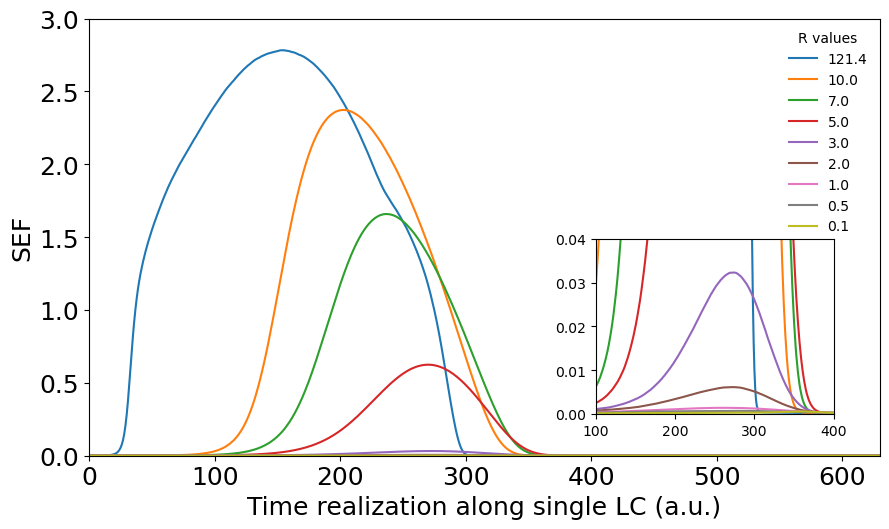

In [21]:
speeds = [0.01,0.121,0.173,0.243,0.405,0.607,1.214,2.43,12.1]
r, v_r, v_theta = 5, 0.01, 0.5
arclength = 2 * np.pi * 0.45 * r

def format_score(x):
    if abs(x) < 0.1:
        return f"{x:.1g}"   # 1 significant figure
    else:
        return f"{x:.1f}"   # 1 decimal place
def format_vel(x):
    if abs(x) < 0.1:
        return f"{x:.2g}"   # 1 significant figure
    else:
        return f"{x:.2f}"   # 1 decimal place
fig, ax = plt.subplots(figsize=(9, 3.6*1.5))


for i in speeds:
    score = mean_lambda * arclength / 5 * i
    r_val = mean_lambda * arclength / (r * i)
    ax.plot(entropy_dict[i], label=f"{format_score(r_val)}")

ax.set_xlim(0, 630)
ax.set_ylim(0, 3)
ax.set_ylabel('SEF', fontsize=18)
ax.set_xlabel('Time realization along single LC (a.u.)', fontsize=18)
ax.tick_params(axis='both', labelsize=18)

# Inset
axins = inset_axes(ax, width="30%", height="40%", loc='lower right',
    bbox_to_anchor=(-0.05, 0.08, 1, 1),  # <-- shift up (increase 0.08 as needed)
    bbox_transform=ax.transAxes)

for i in speeds:
    axins.plot(entropy_dict[i])

axins.set_xlim(100, 400)
axins.set_ylim(0, 0.04)
axins.tick_params(axis='both', labelsize=10)

# Connect inset to zoomed region
# mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.5")

ax.legend(frameon=False,title="R values")

plt.tight_layout()

plt.savefig("supp_fig_velocity.png")
plt.show()